## 📝 Instrucciones


**Sistema de predicción de ventas**

Queremos establecer el almacén de nuestra empresa en otra localización y necesitamos estimar el ritmo de las ventas, que desde la creación de la empresa ha ido en aumento, para los próximos meses, a fin de proveer el espacio que necesitaremos.

## Paso 1: Carga del conjunto de datos


El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre sales.csv. Puedes cargarlos en el código directamente desde el siguiente enlace:

''https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv''

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/raw/sales.csv')
print(df.head())

                         date      sales
0  2022-09-03 17:10:08.079328  55.292157
1  2022-09-04 17:10:08.079328  53.803211
2  2022-09-05 17:10:08.079328  58.141693
3  2022-09-06 17:10:08.079328  64.530899
4  2022-09-07 17:10:08.079328  66.013633


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    str    
 1   sales   366 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.8 KB


In [4]:
df.shape

(366, 2)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sales,366.0,524.963968,275.089698,53.803211,290.186822,520.699468,763.289263,1000.482785


In [6]:
#parseamos date y lo ponemos cono índice
ser = pd.read_csv('../data/raw/sales.csv', parse_dates=['date'], index_col='date')
ser.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


## Paso 2: Construye y analiza la serie temporal


Construye la estructura de datos válida para la serie temporal, grafícala y, a continuación, analízala y responde a las siguientes preguntas:

**¿Cuál es el tensor de la serie temporal?**

**¿Cuál es la tendencia?**

**¿Es estacionaria?**

**¿Existe variabilidad o presencia de ruido?**

_Nota: Un tensor en una serie temporal es la unidad de tiempo mínima para la cual hay datos. Puede ser cada segundo, minuto, hora, día, semana, mes.._

In [16]:
ser.index.to_series().diff()

date
2022-09-03 17:10:08.079328      NaT
2022-09-04 17:10:08.079328   1 days
2022-09-05 17:10:08.079328   1 days
2022-09-06 17:10:08.079328   1 days
2022-09-07 17:10:08.079328   1 days
                              ...  
2023-08-30 17:10:08.079328   1 days
2023-08-31 17:10:08.079328   1 days
2023-09-01 17:10:08.079328   1 days
2023-09-02 17:10:08.079328   1 days
2023-09-03 17:10:08.079328   1 days
Name: date, Length: 366, dtype: timedelta64[us]

**El tensor es diario**

<Axes: xlabel='date'>

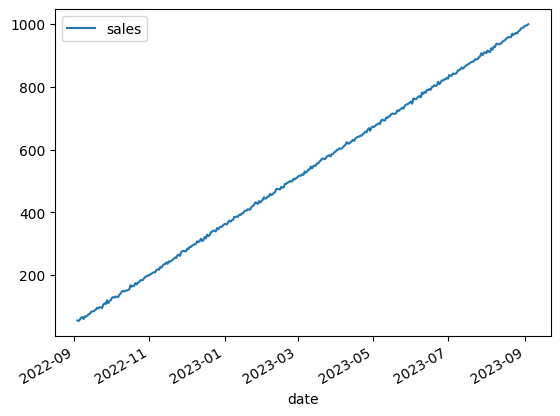

In [17]:
ser.plot(grid=False)

**La tendencia es claramente ascendente y casi perfectamente lineal**

Visualmente se puede confirmar que la serie es claramente estacionaria. Para evaluar la estacionalidad aplicamos la llamada **Dickey-Fuller**

In [ ]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    print('Resultado de la Prueba de Dickey-Fuller:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    return dfoutput

test_stationarity(ser)

ModuleNotFoundError: No module named 'statsmodels'